In [11]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import re
import textwrap
import matplotlib.pyplot as plt
import torch
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm
from datasets import load_dataset
from rouge_score import rouge_scorer

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

from transformers import (
    EncoderDecoderModel,
    AutoTokenizer, AutoConfig
)

In [12]:
raw_train_dataset = load_dataset("knkarthick/samsum", split="train[:15%]")
raw_val_dataset = load_dataset("knkarthick/samsum", split="validation[:15%]")
raw_test_dataset = load_dataset("knkarthick/samsum", split="test[:15%]")

train_texts = raw_train_dataset["dialogue"]
train_summaries = raw_train_dataset["summary"]
val_texts = raw_val_dataset["dialogue"]
val_summaries = raw_val_dataset["summary"]
test_texts = raw_test_dataset["dialogue"]
test_summaries = raw_test_dataset["summary"]

This cell loads the SAMSum dataset. It loads a train, validation, and test set and only loads a specified percentage of the data in order to control the training speed and reduce computational cost. 

In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

train_texts = [clean_text(x) for x in train_texts]
train_summaries = [clean_text(x) for x in train_summaries]
val_texts = [clean_text(x) for x in val_texts]
val_summaries = [clean_text(x) for x in val_summaries]
test_texts = [clean_text(x) for x in test_texts]
test_summaries = [clean_text(x) for x in test_summaries]

print("Sample dialogue:")
print(train_texts[0][:500])
print("\nSample summary:")
print(train_summaries[0])

Sample dialogue:
amanda: i baked cookies. do you want some? jerry: sure! amanda: i'll bring you tomorrow :-)

Sample summary:
amanda baked cookies and will bring jerry some tomorrow.


This cell cleans the data by conveting it to lower case, removes extra whitespace, and strips leading and trailing spaces. It then provides a sample of the dataset to verify the cleaning changes. 

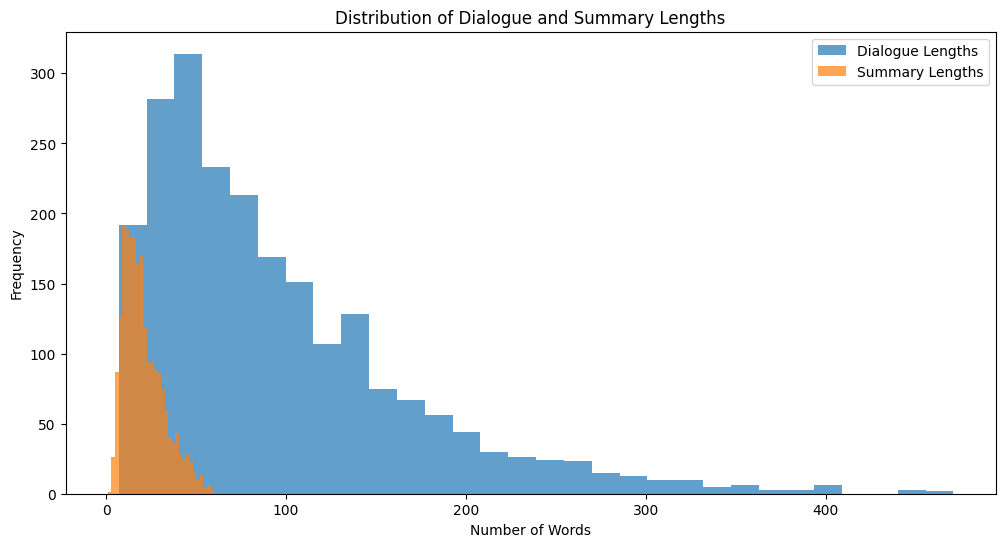

In [14]:
dialogue_lengths = [len(text.split()) for text in train_texts]
summary_lengths = [len(text.split()) for text in train_summaries]

plt.figure(figsize=(12, 6))
plt.hist(dialogue_lengths, bins=30, alpha=0.7, label='Dialogue Lengths')
plt.hist(summary_lengths, bins=30, alpha=0.7, label='Summary Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Dialogue and Summary Lengths')
plt.legend()
plt.show()

Chart showing the number of words in the dialogues and the number of words in the summaries. This helps undertand the structure of the dataset and will help inform decisions regarding input and output length. 

In [15]:
class SummarizationDataset(Dataset):
    def __init__(self, texts, summaries, encoder_tokenizer, decoder_tokenzier, max_len_input=128, max_len_output=32):
        self.texts = texts
        self.summaries = summaries
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenzier
        self.max_len_input = max_len_input
        self.max_len_output = max_len_output
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.encoder_tokenizer(
            self.texts[idx],
            truncation=True, 
            padding='max_length',
            max_length=self.max_len_input,
            return_tensors='pt'
        )
        dec = self.decoder_tokenizer(
            self.summaries[idx], 
            truncation=True,
            padding='max_length',
            max_length=self.max_len_output,
            return_tensors='pt'
        )
        item = {key: val.squeeze(0) for key, val in enc.items()}
        labels = dec['input_ids'].squeeze(0)
        labels[labels == self.decoder_tokenizer.pad_token_id] = -100
        item['labels'] = labels
        return item

This cell defines a summarizationdataset class that handles batching and tokenization and prepares the data for training and eval. It tokenizes dialogues and summaries with the decoder tokenizer and applies truncation and padding to make sure the sequences are the fixed lengths. Padding tokens in the labels are set to -100 to ignore them when calculating loss. 

In [16]:
def init_model():
    encoder_name = "distilbert-base-uncased"  
    decoder_name = "prajjwal1/bert-small"    

   
    decoder_config = AutoConfig.from_pretrained(decoder_name)
    decoder_config.is_decoder = True
    decoder_config.add_cross_attention = True

    
    model = EncoderDecoderModel.from_encoder_decoder_pretrained(
        encoder_name, decoder_name, decoder_config=decoder_config
    )

    
    encoder_tokenizer = AutoTokenizer.from_pretrained(encoder_name)
    decoder_tokenizer = AutoTokenizer.from_pretrained(decoder_name)

    
    if encoder_tokenizer.pad_token is None:
        encoder_tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    if decoder_tokenizer.pad_token is None:
        decoder_tokenizer.add_special_tokens({'pad_token': '[PAD]'})

    
    if decoder_tokenizer.bos_token is None:
        decoder_tokenizer.add_special_tokens({'bos_token': '<BOS>'})

    
    model.encoder.resize_token_embeddings(len(encoder_tokenizer))
    model.decoder.resize_token_embeddings(len(decoder_tokenizer))

   
    model.config.pad_token_id = encoder_tokenizer.pad_token_id
    model.config.decoder_pad_token_id = decoder_tokenizer.pad_token_id
    model.config.decoder_start_token_id = decoder_tokenizer.bos_token_id
    model.config.eos_token_id = decoder_tokenizer.eos_token_id

    
    model.config.use_cache = False
    model.config.max_length = 48
    model.config.min_length = 10
    model.config.num_beams = 4
    model.config.no_repeat_ngram_size = 3
    model.config.repetition_penalty = 2.0
    model.config.length_penalty = 1.0
    model.config.early_stopping = True

    return model, encoder_tokenizer, decoder_tokenizer

This cell initializes the encoder-decoder. Due to issues I was having with my computer I opted to use smaller models for the encoder and decoder. Larger models took extrememley long to train, even on smaller portions of the dataset, and usually resutled in my kernel dying or my entire computer shutting down and restarting. These were chosen to show that the model can learn and improve over epochs and will perform much more effectively on a larger model that is better suited for a dataset this size. The encoder is BERT based as well as the decoder. 
Cross attention is enabled in the decoder, and generational parameters such as, max_length, num_beams, length_penalty were set. It also loads tokenizers for encoder and decoder and adds special tokens (PAD, BOS) if missing. Token embeddings are resized to account for the special tokens. This configures the model for seqtoseq tasks.  

In [17]:
def train_model(model, dataloader, device, encoder_tokenizer, decoder_tokenizer, val_texts, val_summaries,
epochs=5, lr=3e-5, checkpoint_path='checkpoint.pt', eval_samples=10, accumulation_steps=8):

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    best_loss = float('inf')
    model.to(device)

    rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores_per_epoch = []
    losses_per_epoch = []
    for epoch in range(epochs):

        model.train() 
        total_loss = 0 
        optimizer.zero_grad()
        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        for step, batch in enumerate(loop):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss = loss / accumulation_steps
            loss.backward()
            total_loss += loss.item() 
            

            if (step + 1) % accumulation_steps == 0 or step + 1 == len(dataloader):
                optimizer.step()
                optimizer.zero_grad()

            loop.set_postfix(loss=loss.item())
        
        avg_loss = total_loss / len(dataloader)
        losses_per_epoch.append(avg_loss) 
        print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4}") 

        model.eval()
        generated = []

        with torch.no_grad():
            for i in range(eval_samples):
                inputs = encoder_tokenizer(val_texts[i], return_tensors='pt', truncation=True, max_length=126)
                inputs = {k: v.to(device) for k, v in inputs.items()}

                summary_ids = model.generate(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'],
                max_length=64, min_length=10, num_beams=4, no_repeat_ngram_size=3, early_stopping=True) 

                gen_summary = decoder_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
                generated.append(gen_summary)
            
        scores = [ rouge.score(val_summaries[i], generated[i]) for i in range(eval_samples)]

        avg_rouge1 = sum([s['rouge1'].fmeasure for s in scores]) / eval_samples
        avg_rouge2 = sum([s['rouge2'].fmeasure for s in scores]) / eval_samples
        avg_rougeL = sum([s['rougeL'].fmeasure for s in scores]) / eval_samples

        rouge_scores_per_epoch.append((avg_rouge1, avg_rouge2, avg_rougeL))
        print(f"\n Rouge-1: {avg_rouge1:.3f}")
        print(f" Rouge-2: {avg_rouge2:.3f}")
        print(f" Rouge-L: {avg_rougeL:.3f}")


    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(losses_per_epoch) + 1), losses_per_epoch, marker='o', label='Training Loss')
    plt.xlabel('Epoch') 
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    model.eval()
    return model, rouge_scores_per_epoch

This trains the encoder-decoder model. Cross entropy loss to compare target and predicted summaries. Gradient accumulation simulates a larger batch size by accumulating gradients. ROUGE scores are then computed on the validation set after each opoch. Loss curve is also plotted after training. This cell optimizes model parameters to minimize loss and evaluates performance using ROUGE scores. 

In [18]:
def generate_summaries(model, dataset, decoder_tokenizer, device, max_length=32):
    
    summaries_out = []

    model.eval()
    with torch.no_grad():
        for i in range(len(dataset)):
            item = dataset[i]
            input_ids = item['input_ids'].unsqueeze(0).to(device)
            attention_mask = item['attention_mask'].unsqueeze(0).to(device)
            summary_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=max_length, 
            min_length=10, no_repeat_ngram_size=3)
            
            summary = decoder_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
            summaries_out.append(summary)
    return summaries_out

generate_summaries function is created. Inputs are toekenized dialogues form the test set. Beam search is used to improve the quality of the generated summaries. Ouputs decodes the generate3d token IDs to test summaries. 

In [19]:
def main():     
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")  
    elif torch.cuda.is_available():
        device = torch.device("cuda") 
    else:
        device = torch.device("cpu")
    
    print(f"Using device: {device}")

    model, encoder_tokenizer, decoder_tokenizer = init_model()
    train_dataset = SummarizationDataset(train_texts, train_summaries, encoder_tokenizer, decoder_tokenizer, max_len_input=128, max_len_output=32)
    test_dataset = SummarizationDataset(test_texts, test_summaries, encoder_tokenizer, decoder_tokenizer, max_len_input=128, max_len_output=32)

    dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)

    model, rouge_scores = train_model(model, dataloader, device, encoder_tokenizer, decoder_tokenizer, val_texts, val_summaries, 
    epochs=5, lr=3e-5, eval_samples=10, accumulation_steps=4)

    epochs_range = range(1, len(rouge_scores) + 1)
    
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_range, [s[0] for s in rouge_scores], label="Rouge-1", marker='o')
    plt.plot(epochs_range, [s[1] for s in rouge_scores], label="Rouge-2", marker='o')
    plt.plot(epochs_range, [s[2] for s in rouge_scores], label="Rouge-L", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("ROUGE Scores During Training")
    plt.legend()
    plt.show()


    summaries_out = generate_summaries(model, test_dataset, decoder_tokenizer, device)

    for i in range(5):
        print(f"\n{'='*100}")
        print(f"Example {i+1}")
        print(f"{'='*100}")
        print("\nDialogue:")
        print(textwrap.fill(test_texts[i][:500], width=100))

        print("\nTarget Summary:\n")
        print(textwrap.fill(test_summaries[i], width=100))

        print("\nGenerated Summary:\n")
        print(textwrap.fill(summaries_out[i], width=100))

The main() function orchestrates the whoel pipeline. Model and tokenizers are initialized, training and test sets are prepared, the model is trained and evaluated using the ROUGE scores and summaries are generated to compare with target summaries. ROUGE scores are visualized over epochs to show improvement. 

Using device: cpu


Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertModel: ['vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing DistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of the model checkpoint at prajjwal1/bert-small were not used when initializing BertLMHeadModel: ['cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertLMHeadModel from the checkpoint of a model trained on another task or with an

Epoch 1 - Average Loss: 1.556

 Rouge-1: 0.162
 Rouge-2: 0.008
 Rouge-L: 0.115


Epoch 2/5: 100%|██████████| 277/277 [17:04<00:00,  3.70s/it, loss=1.21] 


Epoch 2 - Average Loss: 1.173

 Rouge-1: 0.180
 Rouge-2: 0.016
 Rouge-L: 0.114


...

Epoch 3 - Average Loss: 1.074

 Rouge-1: 0.159
 Rouge-2: 0.032
 Rouge-L: 0.111


Epoch 4/5: 100%|██████████| 277/277 [16:06<00:00,  3.49s/it, loss=0.953]


Epoch 4 - Average Loss: 1.007

 Rouge-1: 0.194
 Rouge-2: 0.026
 Rouge-L: 0.125


Epoch 5/5: 100%|██████████| 277/277 [15:59<00:00,  3.46s/it, loss=0.841]


Epoch 5 - Average Loss: 0.952

 Rouge-1: 0.215
 Rouge-2: 0.043
 Rouge-L: 0.148


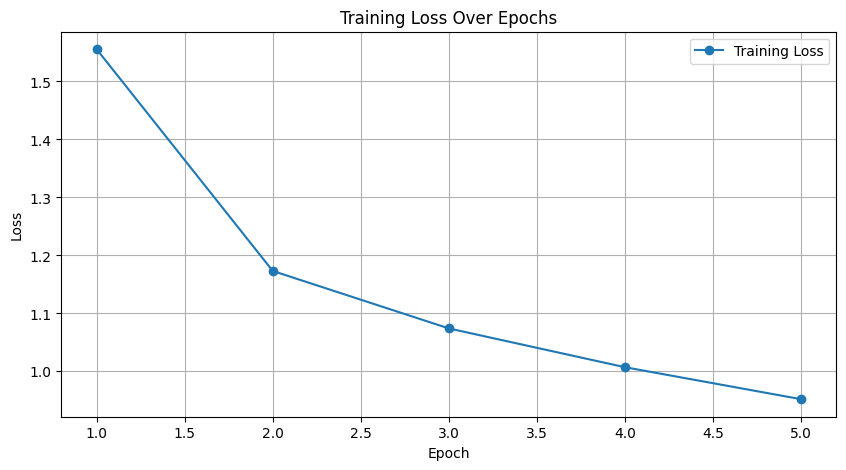

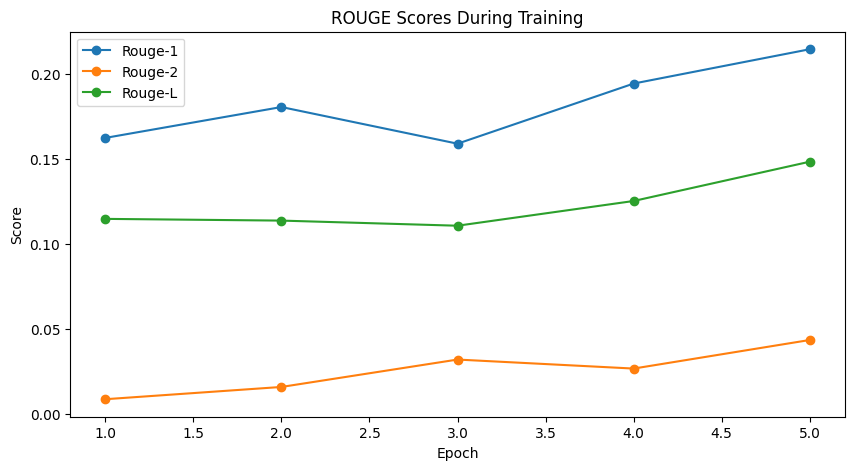


Example 1

Dialogue:
hannah: hey, do you have betty's number? amanda: lemme check hannah: <file_gif> amanda: sorry, can't
find it. amanda: ask larry amanda: he called her last time we were at the park together hannah: i
don't know him well hannah: <file_gif> amanda: don't be shy, he's very nice hannah: if you say so..
hannah: i'd rather you texted him amanda: just text him 🙂 hannah: urgh.. alright hannah: bye amanda:
bye bye

Target Summary:

hannah needs betty's number but amanda doesn't have it. she needs to contact larry.

Generated Summary:

olivia is looking for a new dress. olivia wants to go to the mall. there's a date with olivia and
olivia.

Example 2

Dialogue:
eric: machine! rob: that's so gr8! eric: i know! and shows how americans see russian ;) rob: and
it's really funny! eric: i know! i especially like the train part! rob: hahaha! no one talks to the
machine like that! eric: is this his only stand-up? rob: idk. i'll check. eric: sure. rob: turns out
no! there are some of

In [20]:
main()